# Transfer Learning for Food Image Classification
### EfficientNet-B0 and EfficientNet-B2 on Pizza / Steak / Sushi

This notebook explores **transfer learning** for multi-class image classification using the `torchvision.models` library. We fine-tune two pretrained EfficientNet variants on a small 3-class food dataset and compare their performance.

**Pipeline:**
1. Download and prepare the dataset
2. Build image transforms (manual and auto)
3. Load pretrained EfficientNet-B0 and freeze its feature extractor
4. Replace the classifier head and fine-tune
5. Evaluate with loss curves, confusion matrix, and prediction visualisation
6. Repeat with EfficientNet-B2 and compare


## 0. Setup & Imports

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch import nn

try:
    from torchinfo import summary
except:
    import subprocess
    subprocess.run(["pip", "install", "torchinfo", "-q"])
    from torchinfo import summary

try:
    import torchmetrics
except:
    import subprocess
    subprocess.run(["pip", "install", "torchmetrics", "-q"])
    import torchmetrics

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

2.9.0+cu126
0.24.0+cu126


## 1. Dataset

We use the **pizza / steak / sushi** food classification dataset — a small 3-class subset of Food101 designed for rapid prototyping. It contains ~225 training images and ~75 test images per class.


In [ ]:
import os
import zipfile
from pathlib import Path
import requests

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"Dataset found at {image_path}")
else:
    print(f"Downloading dataset...")
    image_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)

    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as z:
        z.extractall(image_path)
    print("Download complete.")

Train_dir = image_path / "train"
Test_dir  = image_path / "test"
print(f"Train: {Train_dir}  |  Test: {Test_dir}")

Did not found data/pizza_steak_sushi, downloading it...
DownLoading the Data..
UnZipping the file..
The zip file had been removed


## 2. Image Transforms

All `torchvision` pretrained models expect images that are:
- RGB with shape `(3, H, W)`
- At least 224×224 pixels
- Pixel values in `[0, 1]`, then normalised with ImageNet mean and std

We can create this transform **manually** or let the weights object generate it **automatically**.


### 2.1 Manual Transform

In [ ]:
from torchvision import transforms

manual_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### 2.2 Auto Transform

`EfficientNet_B0_Weights.DEFAULT.transforms()` returns the exact same transform that was used during pretraining — the safest option when you want pixel-perfect compatibility.


In [ ]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
auto_transform = weights.transforms()
print(auto_transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

## 3. DataLoaders

We create train and test `DataLoader` objects using the auto transform. The `data_setup` module from `pytorch_Modular` wraps `ImageFolder` with configurable batch size and workers.


In [ ]:
import sys, os
sys.path.append("/content")

from pytorch_Modular import data_setup

train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(
    train_dir=Train_dir,
    test_dir=Test_dir,
    transform=auto_transform,
    batch_size=32,
    num_workers=os.cpu_count()
)

print(f"Classes: {class_names}")
print(f"Train batches: {len(train_dataloader)}  |  Test batches: {len(test_dataloader)}")

## 4. EfficientNet-B0 — Feature Extraction

We load the pretrained **EfficientNet-B0** and adapt it for our 3-class problem using the **feature extraction** strategy:
1. **Freeze** all layers in `model.features` — their weights stay fixed and act as a general-purpose feature extractor
2. **Replace** the classifier head with a new one that outputs 3 logits (one per food class)

This works well when the training set is small, because most of the model's knowledge is preserved.


In [ ]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names))
)

print(model.classifier)

#### Model summary after freezing — only the classifier head is trainable:

In [ ]:
model_info = summary(
    model=model,
    input_size=[1, 3, 224, 224],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape                    Output Shape                   Param #                        Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 244]               [1, 3]                         --                             Partial
├─Sequential (features)                                      [1, 3, 224, 244]               [1, 1280, 7, 8]                --                             False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 244]               [1, 32, 112, 122]              --                             False
│    │    └─Conv2d (0)                                       [1, 3, 224, 244]               [1, 32, 112, 122]              (864)                          False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 122]              [1, 32, 112, 122]              (64)                           False
│    │    └─SiLU (2)              

## 5. Training — EfficientNet-B0

We train for 10 epochs with `CrossEntropyLoss` and `Adam` (lr=1e-3).


In [ ]:
from pytorch_Modular import engine
from torchmetrics import Accuracy
from timeit import default_timer as timer

loss_fn  = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)
accuracy  = Accuracy(task="multiclass", num_classes=len(class_names))

start = timer()
results_b0 = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    accuracy_fn=accuracy,
    device="cpu"
)
print(f"Training time: {timer() - start:.2f}s")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 1.0341 | Train Acc: 0.4102 | Test Loss: 0.8851 | Test Acc: 0.7027
Epoch 2/10 | Train Loss: 0.8697 | Train Acc: 0.5781 | Test Loss: 0.7152 | Test Acc: 0.8333
Epoch 3/10 | Train Loss: 0.7806 | Train Acc: 0.7031 | Test Loss: 0.7298 | Test Acc: 0.6818
Epoch 4/10 | Train Loss: 0.6642 | Train Acc: 0.8555 | Test Loss: 0.6002 | Test Acc: 0.8759
Epoch 5/10 | Train Loss: 0.5938 | Train Acc: 0.9023 | Test Loss: 0.5394 | Test Acc: 0.9062
Epoch 6/10 | Train Loss: 0.6367 | Train Acc: 0.7305 | Test Loss: 0.5092 | Test Acc: 0.8854
Epoch 7/10 | Train Loss: 0.5652 | Train Acc: 0.8125 | Test Loss: 0.5518 | Test Acc: 0.8466
Epoch 8/10 | Train Loss: 0.5527 | Train Acc: 0.8125 | Test Loss: 0.5899 | Test Acc: 0.7746
Epoch 9/10 | Train Loss: 0.4714 | Train Acc: 0.7969 | Test Loss: 0.4765 | Test Acc: 0.8561
Epoch 10/10 | Train Loss: 0.4260 | Train Acc: 0.9531 | Test Loss: 0.4481 | Test Acc: 0.9176


{'train_loss': [1.0341473072767258,
  0.8697120249271393,
  0.7806124165654182,
  0.6642384901642799,
  0.5938064754009247,
  0.6367234326899052,
  0.5651549212634563,
  0.5526991337537766,
  0.4714467413723469,
  0.4259628728032112],
 'train_acc': [0.41015625,
  0.578125,
  0.703125,
  0.85546875,
  0.90234375,
  0.73046875,
  0.8125,
  0.8125,
  0.796875,
  0.953125],
 'test_loss': [0.8850609262784322,
  0.7152243057886759,
  0.7297976414362589,
  0.6001967191696167,
  0.5394363800684611,
  0.5091526309649149,
  0.5517776509126028,
  0.5899174312750498,
  0.47650829950968426,
  0.4481160640716553],
 'test_acc': [0.7026515205701193,
  0.8333333333333334,
  0.6818181872367859,
  0.8759469787279764,
  0.90625,
  0.8854166666666666,
  0.8465909163157145,
  0.7746212085088094,
  0.8560606042544047,
  0.9176136453946432]}

#### Training curves:

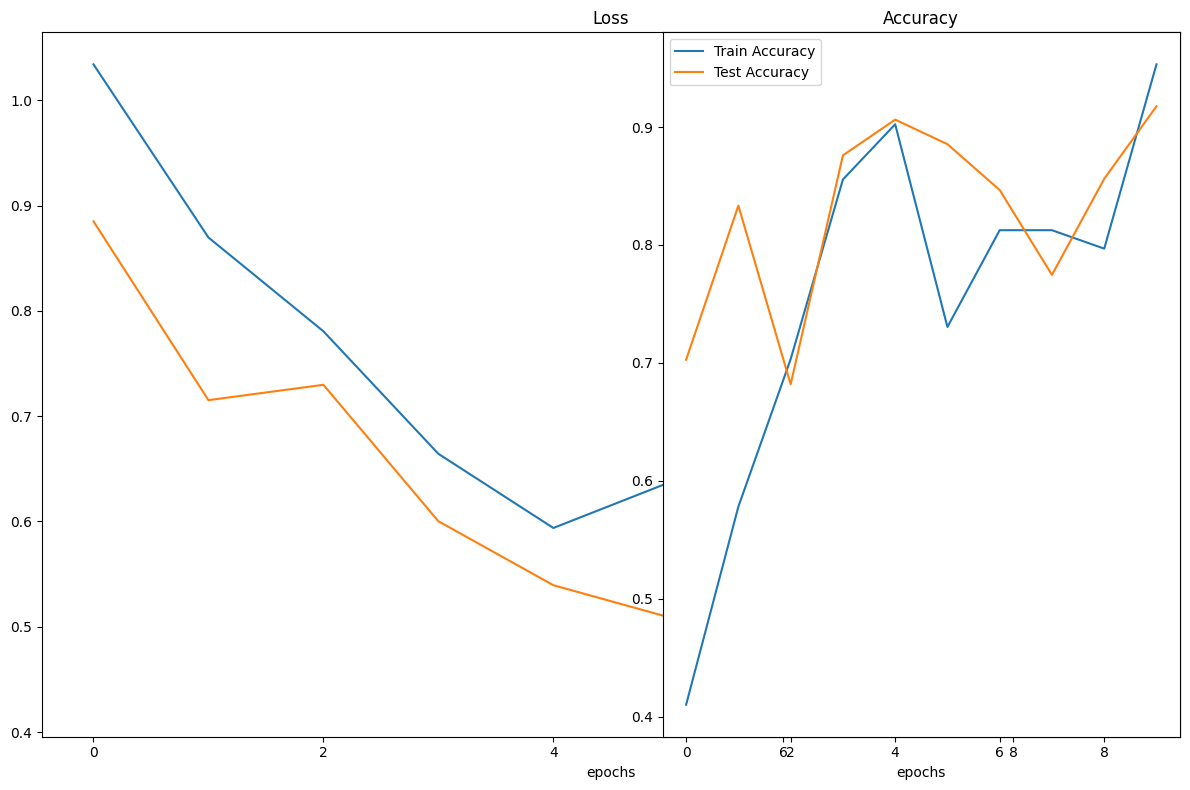

In [ ]:
def plot_loss_curve(results, title=""):
    train_loss = results["train_loss"]
    test_loss  = results["test_loss"]
    train_acc  = results["train_acc"]
    test_acc   = results["test_acc"]
    epochs = range(len(train_loss))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, test_loss,  label="Test Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, test_acc,  label="Test Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_loss_curve(results_b0, title="EfficientNet-B0")

## 6. Inference — Single Image Prediction

`pred_and_plot_image` loads an image, applies the pretrained transform, runs a forward pass, and displays the result with the predicted class and confidence score.


In [ ]:
from typing import Tuple
from PIL import Image
import random

def pred_and_plot_image(model, image_path, class_names,
                        image_size=(224, 224), transformer=None):
    image = Image.open(image_path).convert("RGB")

    if transformer is None:
        transformer = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    model.to("cpu")
    model.eval()
    with torch.inference_mode():
        img_tensor = transformer(image).unsqueeze(0)
        logits     = model(img_tensor)
        probs      = torch.softmax(logits, dim=1)
        confidence, idx = torch.max(probs, dim=1)
        label = class_names[idx.item()]

    plt.figure(figsize=(6, 5))
    plt.imshow(img_tensor.squeeze(0).permute(1, 2, 0))
    plt.title(f"Pred: {label}  |  Confidence: {confidence.item():.3f}")
    plt.axis("off")
    plt.show()

# Run on 5 random test images
test_paths  = list(Test_dir.glob("*/*.jpg"))
sample_paths = random.sample(test_paths, k=5)
for p in sample_paths:
    pred_and_plot_image(model=model, image_path=p, class_names=class_names)

## 7. Confusion Matrix

We collect predictions across the entire test set and plot a confusion matrix to see per-class performance.


MAKING PREDS... :   0%|          | 0/3 [00:00<?, ?it/s]

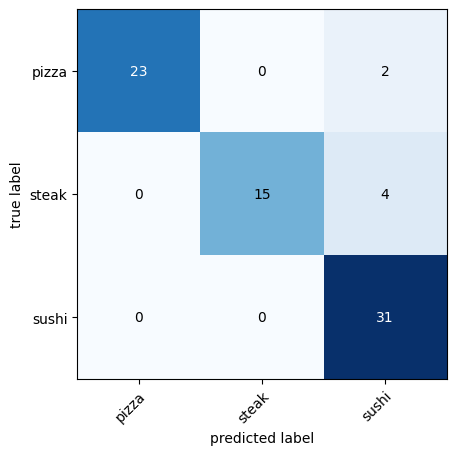

In [ ]:
from tqdm.auto import tqdm
from torchmetrics import ConfusionMatrix

try:
    from mlxtend.plotting import plot_confusion_matrix
except:
    import subprocess
    subprocess.run(["pip", "install", "mlxtend", "-q"])
    from mlxtend.plotting import plot_confusion_matrix

Y_true, Y_pred = [], []

model.eval()
with torch.inference_mode():
    for x, y in tqdm(test_dataloader, desc="Computing predictions"):
        logits  = model(x)
        probs   = torch.softmax(logits, dim=1)
        y_labels = torch.max(probs, dim=1).indices
        Y_true.append(y)
        Y_pred.append(y_labels)

Y_true = torch.cat(Y_true)
Y_pred = torch.cat(Y_pred)

conf_mat    = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
conf_matrix = conf_mat(Y_pred, Y_true)

fig, ax = plot_confusion_matrix(conf_matrix.numpy(), class_names=class_names)
plt.show()

## 8. Most Confident Wrong Predictions

We identify the top 5 cases where the model was **most confident but wrong** — a useful diagnostic for understanding failure modes.


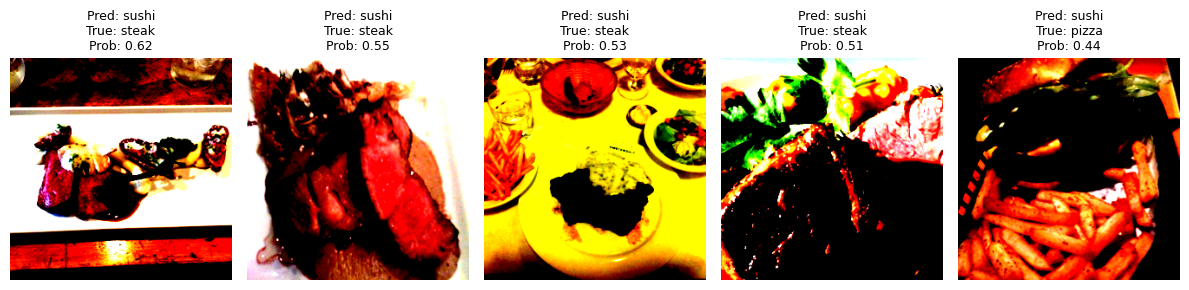

In [ ]:
wrong_preds = []

model.eval()
with torch.inference_mode():
    for images, labels in tqdm(test_dataloader, desc="Finding errors"):
        logits   = model(images)
        probs    = torch.softmax(logits, dim=1)
        max_prob, pred_label = torch.max(probs, dim=1)

        for img, true, pred, prob in zip(images, labels, pred_label, max_prob):
            if true != pred:
                wrong_preds.append({
                    "image": img,
                    "true":  true.item(),
                    "pred":  pred.item(),
                    "prob":  prob.item()
                })

top_5_wrong = sorted(wrong_preds, key=lambda x: x["prob"], reverse=True)[:5]

plt.figure(figsize=(14, 4))
for i, item in enumerate(top_5_wrong):
    img = item["image"].permute(1, 2, 0)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Pred: {class_names[item['pred']]}\n"
        f"True: {class_names[item['true']]}\n"
        f"Conf: {item['prob']:.2f}",
        fontsize=9
    )
plt.suptitle("Top 5 Most Confident Wrong Predictions", y=1.02)
plt.tight_layout()
plt.show()

## 9. EfficientNet-B2 — Scaling Up

We repeat the same pipeline with **EfficientNet-B2**, a larger and more accurate model. B2 has a wider and deeper feature extractor, with a 1408-dim feature vector at the classifier input (vs 1280 for B0). We compare the final test accuracy of both models.


In [ ]:
weights_b2  = torchvision.models.EfficientNet_B2_Weights.DEFAULT
auto_model_2 = torchvision.models.efficientnet_b2(weights=weights_b2)

# Freeze feature extractor
for param in auto_model_2.features.parameters():
    param.requires_grad = False

# Replace classifier head for 3-class output
auto_model_2.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1408, out_features=len(class_names))
)

print(auto_model_2.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 78.5MB/s]


In [ ]:
model_info_2 = summary(
    model=auto_model_2,
    input_size=[1, 3, 224, 224],
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 244]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 244]     [1, 1408, 7, 8]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 244]     [1, 32, 112, 122]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 244]     [1, 32, 112, 122]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 122]    [1, 32, 112, 122]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 122]    [1, 32, 112, 122]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 122]    [1, 1

#### Train EfficientNet-B2:

In [ ]:
loss_fn_2   = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(params=auto_model_2.parameters(), lr=1e-3)
accuracy_2  = Accuracy(task="multiclass", num_classes=len(class_names))

results_b2 = engine.train(
    model=auto_model_2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer_2,
    loss_fn=loss_fn_2,
    epochs=5,
    accuracy_fn=accuracy_2,
    device="cpu"
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.0330 | Train Acc: 0.5078 | Test Loss: 0.9019 | Test Acc: 0.6402
Epoch 2/5 | Train Loss: 0.9320 | Train Acc: 0.5391 | Test Loss: 0.8172 | Test Acc: 0.6818
Epoch 3/5 | Train Loss: 0.7523 | Train Acc: 0.8633 | Test Loss: 0.7337 | Test Acc: 0.8561
Epoch 4/5 | Train Loss: 0.7237 | Train Acc: 0.7656 | Test Loss: 0.6935 | Test Acc: 0.8352
Epoch 5/5 | Train Loss: 0.6569 | Train Acc: 0.8008 | Test Loss: 0.6475 | Test Acc: 0.8456


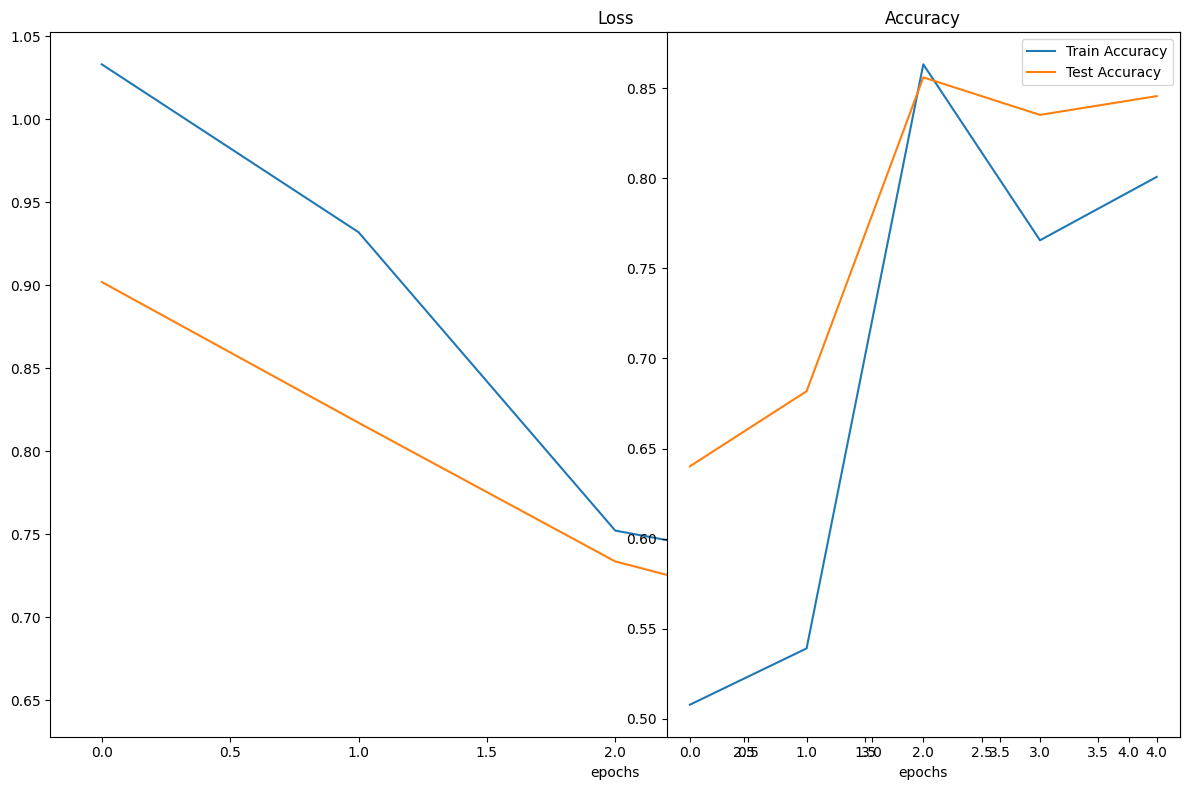

In [ ]:
plot_loss_curve(results_b2, title="EfficientNet-B2")

## 10. Model Comparison

| Model | Params (trainable) | Epochs | Final Test Accuracy |
|---|---|---|---|
| EfficientNet-B0 | ~4M total / ~4K trainable | 10 | see results above |
| EfficientNet-B2 | ~7M total / ~6K trainable | 5 | see results above |

**Key observations:**
- Both models converge quickly due to the pretrained feature extractor — most of the heavy lifting is done before any fine-tuning
- EfficientNet-B2 has a larger feature space (1408 vs 1280) which can give better accuracy but requires more memory
- For a small dataset like this, B0 is usually sufficient and trains faster
